# Smart River EWS - Machine Learning Playbook
Playbook ini adalah panduan interaktif (Jupyter-style) untuk melatih model Machine Learning 
berdasarkan dataset `flood_dataset.csv` yang telah kita buat.

Karena data kita berbentuk tabular (kolom dan baris numerik/kategori), kita akan menggunakan 
algoritma **Random Forest Classifier** yang sangat tangguh dalam menangani data sensor yang 
memiliki noise, serta mampu mencari pola antara curah hujan dan tingkat ketinggian air.


### 1. Import Library yang Dibutuhkan
Pastikan Anda sudah menginstall library pendukung. Jika belum, jalankan di terminal:
`pip install pandas numpy scikit-learn matplotlib seaborn`


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import json

print("Libraries berhasil di-import!")


Libraries berhasil di-import!


### 2. Memuat dan Eksplorasi Dataset (Load Dataset)
Kita akan memuat dataset CSV utama kita dan melihat beberapa baris pertamanya.


In [3]:
# Load Data
df = pd.read_csv('flood_dataset.csv')

# Menampilkan 5 data teratas
print("Sample Data:")
display(df.head())

print("\nDistribusi Status Banjir:")
print(df['status'].value_counts())


Sample Data:


,timestamp,water_level_cm,rainfall_mm,weather_condition,ai_visual,peil_scale,status
0,2026-03-27 08:00:00,18.5,0.0,Cerah,Normal / Clear,19,Aman
1,2026-03-27 08:15:00,18.8,0.0,Cerah,Normal / Clear,19,Aman
2,2026-03-27 08:30:00,17.8,0.0,Cerah,Normal / Clear,18,Aman
3,2026-03-27 08:45:00,15.3,0.0,Cerah,Normal / Clear,15,Aman
4,2026-03-27 09:00:00,13.4,0.0,Cerah,Normal / Clear,13,Aman



Distribusi Status Banjir:
status
Bahaya     102
Aman        43
Waspada      9
Siaga        6
Name: count, dtype: int64


### 3. Visualisasi Pola Ketinggian Air dan Curah Hujan
Mari kita lihat bagaimana grafik time-series ketinggian air dan curah hujan dari data simulasi kita.


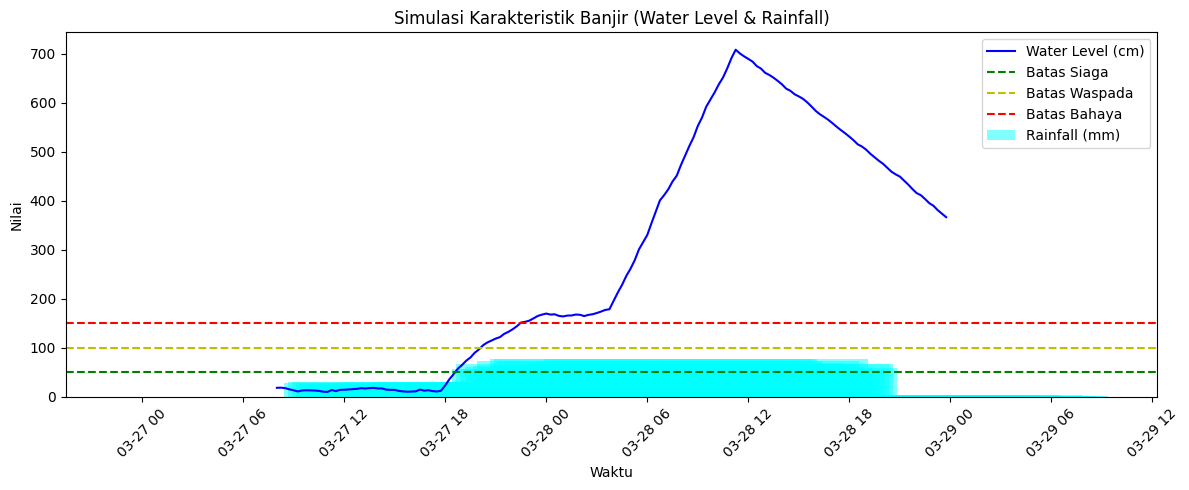

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(df['timestamp']), df['water_level_cm'], label='Water Level (cm)', color='blue')
plt.bar(pd.to_datetime(df['timestamp']), df['rainfall_mm'], label='Rainfall (mm)', color='cyan', alpha=0.5)

plt.axhline(y=50, color='g', linestyle='--', label='Batas Siaga')
plt.axhline(y=100, color='y', linestyle='--', label='Batas Waspada')
plt.axhline(y=150, color='r', linestyle='--', label='Batas Bahaya')

plt.title('Simulasi Karakteristik Banjir (Water Level & Rainfall)')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### 4. Preprocessing Data (Persiapan Pelatihan)
Model ML membutuhkan angka, sehingga kategori teks (seperti cuaca dan status) harus diubah (encoding).
Feature (X) yang kita gunakan: `water_level_cm` dan `rainfall_mm`.
Target (y) yang akan diprediksi: `status`.


In [6]:
# Encoding target 'status' menjadi angka
le_status = LabelEncoder()
df['status_encoded'] = le_status.fit_transform(df['status'])

# Encoding categorical feature 'weather_condition'
le_weather = LabelEncoder()
df['weather_encoded'] = le_weather.fit_transform(df['weather_condition'])

# Definisi Fitur (X) dan Target (y)
X = df[['water_level_cm', 'rainfall_mm', 'weather_encoded']]
y = df['status_encoded']

# Membagi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total data latih: {len(X_train)} baris")
print(f"Total data uji: {len(X_test)} baris")


Total data latih: 128 baris
Total data uji: 32 baris


### 5. Melatih Model (Model Training - Random Forest)
Kita inisialisasi algoritma Random Forest dan melatihnya dengan `X_train` dan `y_train`.


In [7]:
# Inisialisasi Model Random Forest
# n_estimators=100 berarti menggunakan 100 "pohon keputusan" untuk hasil yang robust
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

# Proses Training (Melatih Model)
rf_model.fit(X_train, y_train)

print("Pelatihan Model Selesai!")


Pelatihan Model Selesai!


### 6. Evaluasi Model (Model Evaluation)
Kita tes model dengan data uji (`X_test`) lalu mencocokkannya dengan jawaban asli (`y_test`).


In [8]:
# Melakukan prediksi pada data uji
y_pred = rf_model.predict(X_test)

# Mengembalikan nilai angka ke teks asli ('Aman', 'Siaga', dll) untuk pembacaan
y_test_labels = le_status.inverse_transform(y_test)
y_pred_labels = le_status.inverse_transform(y_pred)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test_labels, y_pred_labels))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        Aman       1.00      1.00      1.00         9
      Bahaya       1.00      1.00      1.00        20
       Siaga       1.00      1.00      1.00         1
     Waspada       1.00      1.00      1.00         2

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



### 7. Simulasi Decision Fusion (AND Logic) di Sistem Backend
Sesuai rancangan arsitektur EWS Anda, Backend akan menggabungkan prediksi dari Sensor (ML Tabular) 
dan hasil Vision (Computer Vision API). Ini adalah contoh sederhana implementasinya.


In [ ]:
print("\n--- SIMULASI DECISION FUSION (AND LOGIC) ---")

# 1. Anggap kita dapat data Real-time dari Sensor IoT (Misal dari ESP32)
live_sensor_data = pd.DataFrame([{
    'water_level_cm': 75.2,
    'rainfall_mm': 60.5,
    'weather_encoded': le_weather.transform(['Hujan Lebat'])[0]
}])

# 2. Model ML kita memprediksi status berdasarkan sensor
sensor_prediction_encoded = rf_model.predict(live_sensor_data)[0]
sensor_status = le_status.inverse_transform([sensor_prediction_encoded])[0]
print(f"Prediksi AI Sensor: {sensor_status}")

# 3. Anggap kita memanggil data JSON dari hasil model Computer Vision (YOLO/CNN)
with open('cv_vision_data.json', 'r') as f:
    cv_data_list = json.load(f)
    latest_cv_data = cv_data_list[-35] # Ambil asumsikan data saat tinggi
    cv_flood_detected = latest_cv_data['flood_detected']

print(f"Hasil Model Computer Vision (Validasi Kamera): Flood Detected = {cv_flood_detected}")

# 4. DECISION FUSION: Penggabungan untuk Eksekusi Relay / Sirene
print("\n[ Keputusan Sistem Backend ]")
if sensor_status == "Bahaya" and cv_flood_detected == True:
    print("🚨 STATUS: BAHAYA VALID! MEMICU RELAY SIRENE DAN LAMPU ROTARY! 🚨")
elif sensor_status == "Bahaya" or sensor_status == "Waspada" and not cv_flood_detected:
    print("⚠️ STATUS: WASPADA SENSOR. Visul kamera TIDAK konfirmasi banjir. (Bisa jadi anomali sensor/sampah)")
else:
    print("✅ STATUS: AMAN / TERKENDALI")



--- SIMULASI DECISION FUSION (AND LOGIC) ---
Prediksi AI Sensor: Aman
Hasil Model Computer Vision (Validasi Kamera): Flood Detected = True

[ Keputusan Sistem Backend ]
✅ STATUS: AMAN / TERKENDALI


### 8. Menyimpan Model (Export Model)

In [12]:
import joblib
import os

# Memastikan kita punya folder output terpisah (optional tapi clean)
output_dir = "models/flood_dataset"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 1. Simpan Model ML (Random Forest)
model_path = os.path.join(output_dir, "rf_ews_model.pkl")
joblib.dump(rf_model, model_path)
print(f"✅ Model berhasil diekspor ke: {model_path}")

# 2. Simpan Label Encoders (Penting untuk konversi teks "Hujan Lebat" -> angka dan angka -> "Bahaya")
status_encoder_path = os.path.join(output_dir, "le_status.pkl")
weather_encoder_path = os.path.join(output_dir, "le_weather.pkl")

joblib.dump(le_status, status_encoder_path)
joblib.dump(le_weather, weather_encoder_path)
print(f"✅ Label Encoders berhasil diekspor ke folder: {output_dir}")

✅ Model berhasil diekspor ke: models/flood_dataset\rf_ews_model.pkl
✅ Label Encoders berhasil diekspor ke folder: models/flood_dataset
